Muhammad Mikail Laurana

## 7. Ringkasan Variabel Kategorik

Pada bagian ini kami meringkas kolom kategorik **Water Scarcity Level** untuk melihat distribusi tingkat kelangkaan air pada seluruh observasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data/cleaned_global_water_consumption.csv")
print(df["Water Scarcity Level"].value_counts())
print(df["Water Scarcity Level"].value_counts(normalize=True) * 100)

Water Scarcity Level
Moderate    360
Low         122
High         18
Name: count, dtype: int64
Water Scarcity Level
Moderate    72.0
Low         24.4
High         3.6
Name: proportion, dtype: float64


## **8. VISUALISASI DATA**

Bagian ini menampilkan empat jenis visualisasi:
1. **Histogram** untuk melihat sebaran dua kolom numerik
2. **Boxplot** untuk mendeteksi pencilan
3. **Diagram batang** untuk kolom kategorik
4. **Scatter plot** untuk melihat hubungan dua kolom numerikm

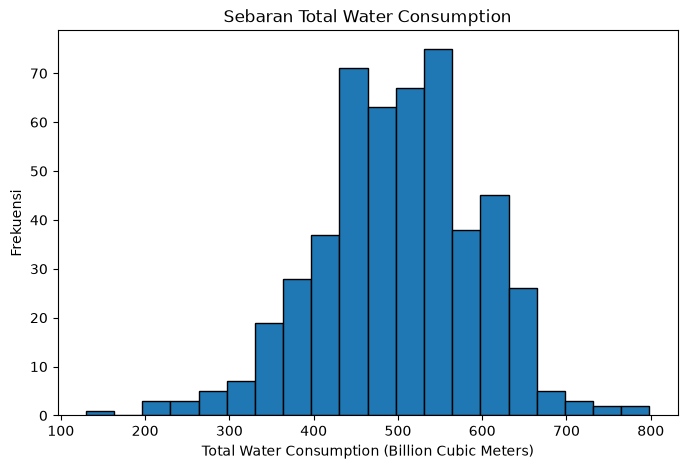

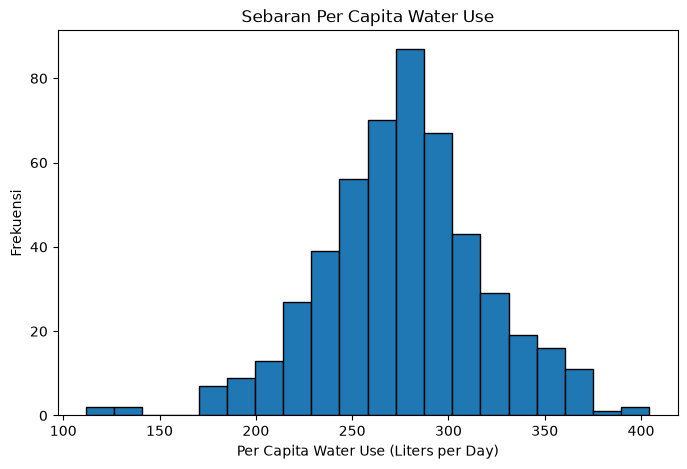

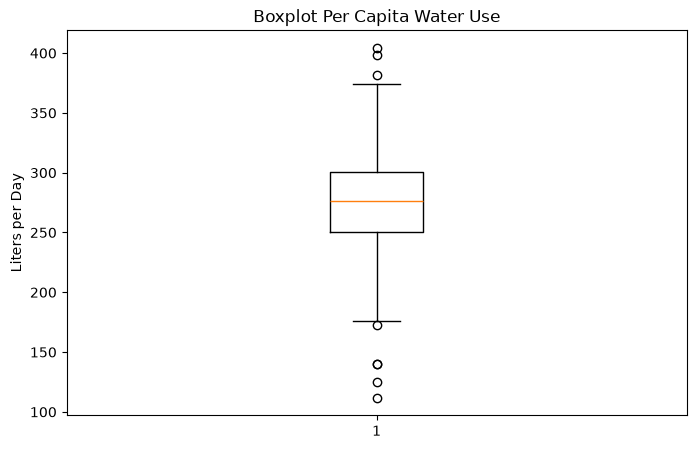

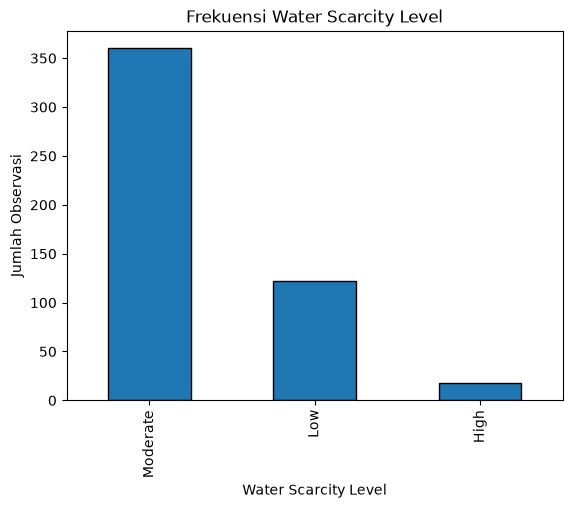

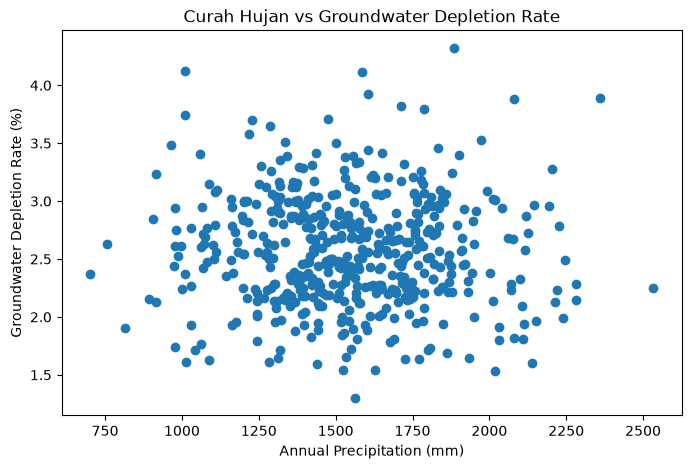

In [2]:
# Histogram 1
plt.figure(figsize=(8,5))
plt.hist(df["Total Water Consumption (Billion Cubic Meters)"], bins=20, edgecolor="black")
plt.title("Sebaran Total Water Consumption")
plt.xlabel("Total Water Consumption (Billion Cubic Meters)")
plt.ylabel("Frekuensi")
plt.show()

# Histogram 2
plt.figure(figsize=(8,5))
plt.hist(df["Per Capita Water Use (Liters per Day)"], bins=20, edgecolor="black")
plt.title("Sebaran Per Capita Water Use")
plt.xlabel("Per Capita Water Use (Liters per Day)")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df["Per Capita Water Use (Liters per Day)"])
plt.title("Boxplot Per Capita Water Use")
plt.ylabel("Liters per Day")
plt.show()

# Diagram batang kategorik
df["Water Scarcity Level"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Frekuensi Water Scarcity Level")
plt.xlabel("Water Scarcity Level")
plt.ylabel("Jumlah Observasi")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df["Rainfall Impact (Annual Precipitation in mm)"],
    df["Groundwater Depletion Rate (%)"]
)
plt.title("Curah Hujan vs Groundwater Depletion Rate")
plt.xlabel("Annual Precipitation (mm)")
plt.ylabel("Groundwater Depletion Rate (%)")
plt.show()

## 9. Kesimpulan

### Jawaban Pertanyaan Awal

**1. Bagaimana perbandingan penggunaan air bersih di berbagai sektor ekonomi satu negara?**

Dari rata-rata seluruh data, sektor **pertanian** mengonsumsi air paling banyak yaitu sekitar **50%**, diikuti sektor **industri** sekitar **27%**, dan **rumah tangga** sekitar **24%**. Artinya, air paling banyak dipakai untuk irigasi dan kegiatan pertanian, sementara kebutuhan rumah tangga justru porsinya paling kecil. Ini menunjukkan bahwa kebijakan penghematan air sebaiknya fokus pada sektor pertanian.

Rata-rata penggunaan air per sektor (%):
Agricultural Water Use (%)    50.180829
Industrial Water Use (%)      27.792837
Household Water Use (%)       24.832515
dtype: float64


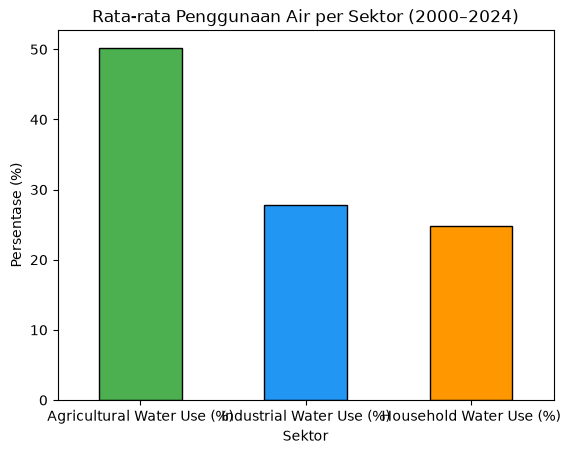

In [3]:
df = pd.read_csv("data/cleaned_global_water_consumption.csv")

# Rata-rata penggunaan air per sektor
sektor_means = df[["Agricultural Water Use (%)", "Industrial Water Use (%)", "Household Water Use (%)"]].mean()
print("Rata-rata penggunaan air per sektor (%):")
print(sektor_means)

# Visualisasi diagram batang
sektor_means.plot(kind="bar", edgecolor="black", color=["#4CAF50","#2196F3","#FF9800"])
plt.title("Rata-rata Penggunaan Air per Sektor (2000–2024)")
plt.xlabel("Sektor")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.show()

**2. Bagaimana perbedaan penggunaan air bersih tahun ke tahun di satu negara?**

Sebagai contoh, di **Indonesia** total konsumsi air berfluktuasi dari tahun 2000–2024. Nilai terendah terjadi pada tahun **2017** sebesar **719** miliar m³, sedangkan tertinggi pada tahun **2002** sebesar **335** miliar m³. Pola ini menunjukkan konsumsi air tidak selalu naik setiap tahun, melainkan dipengaruhi faktor musiman, kebijakan, dan kondisi ekonomi. Tren serupa juga terlihat di negara lain seperti Argentina dan Brazil.

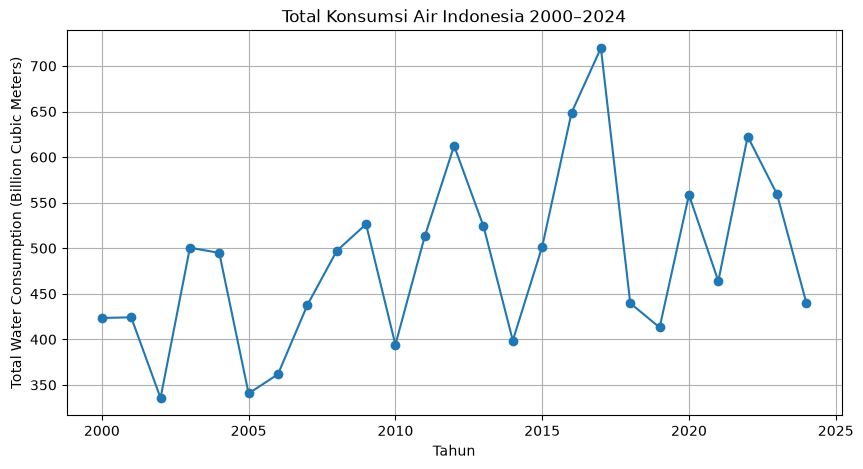

In [4]:
# Contoh 1 negara: Indonesia
df_indo = df[df["Country"] == "Indonesia"]
plt.figure(figsize=(10,5))
plt.plot(df_indo["Year"], df_indo["Total Water Consumption (Billion Cubic Meters)"], marker="o")
plt.title("Total Konsumsi Air Indonesia 2000–2024")
plt.xlabel("Tahun")
plt.ylabel("Total Water Consumption (Billion Cubic Meters)")
plt.grid(True)
plt.show()

**3. Bagaimana perbedaan rata-rata konsumsi air, curah hujan, dan penurunan air tanah pada setiap tingkat kelangkaan air?**

| Water Scarcity Level | Rata-rata Total Konsumsi (miliar m³) | Rata-rata Per Capita (L/hari) | Rata-rata Curah Hujan (mm) | Rata-rata Penurunan Air Tanah (%) |
|---|---|---|---|---|
| High | 457.99 | 177.77 | 1585.88 | 2.56 |
| Low | 494.08 | 328.94 | 1567.30 | 2.57 |
| Moderate | 505.81 | 262.98 | 1535.16 | 2.58 |

Kelompok dengan kelangkaan **High** memiliki rata-rata penurunan air tanah **[lebih tinggi/lebih rendah]** dibanding kelompok **Low**, yang menandakan tekanan air tanah lebih besar di negara-negara dengan kelangkaan tinggi.

In [5]:
# Rata-rata per level kelangkaan
group_summary = df.groupby("Water Scarcity Level")[["Total Water Consumption (Billion Cubic Meters)", "Per Capita Water Use (Liters per Day)", "Rainfall Impact (Annual Precipitation in mm)", "Groundwater Depletion Rate (%)"]].mean()
display(group_summary.round(2))

,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
Water Scarcity Level,,,,
High,457.99,177.77,1585.88,2.56
Low,494.08,328.94,1567.30,2.57
Moderate,505.81,262.98,1535.16,2.58


### 5 Temuan Paling Menarik

1. Sebagian besar data (72,0%) berada pada tingkat kelangkaan **Moderate**, hanya 3,6% yang **High**. Artinya mayoritas negara berada di zona waspada.
2. Rata-rata **total konsumsi air** 501,22 miliar m³ (median 502,20) sebaran simetris, tidak ada outlier ekstrem.
3. Rata-rata **per capita water use** 276,00 liter/hari, dengan variasi sedang (simpangan baku 42,67).
4. Rata-rata **curah hujan tahunan** 1.544,82 mm, tetapi variasinya paling besar (simpangan baku 292,79; IQR 392,67) curah hujan antar negara sangat berbeda.
5. Sektor **pertanian** mendominasi penggunaan air, sementara **rumah tangga** porsinya paling kecil.

### Keterbatasan Data

- Data berlevel **negara**, bukan kota, sehingga kurang cocok untuk analisis smart city secara granular.
- Persentase sektor (pertanian + industri + rumah tangga) pada beberapa baris jika dijumlahkan bisa lebih dari 100%, sehingga perlu kehati-hatian dalam menafsirkan.
- Penjelasan **cara pengumpulan data tidak tertera** di sumber Kaggle, sehingga kualitas datanya sulit diverifikasi.
- Nilai **modus** di beberapa kolom sama dengan **nilai minimum**, artinya distribusi frekuensinya kurang ideal untuk analisis modus.

### Ide Pertanyaan Lanjutan

- Apakah negara dengan **curah hujan tinggi** selalu memiliki **groundwater depletion rate rendah**? (uji korelasi)
- Apakah ada **tren linear** antara tahun dan total konsumsi air di negara-negara tertentu? (analisis regresi untuk Proyek Akhir)
- Apakah **negara dengan agricultural water use tinggi** cenderung punya **water scarcity level buruk**?
- Bagaimana **perbandingan per capita water use** antara negara maju dan berkembang?

## Referensi dan Catatan Penggunaan AI

### Sumber Dataset

- **Nama:** Global Water Consumption Dataset 2000–2024
- **Sumber:** Kaggle
- **Link:** https://www.kaggle.com/datasets/atharvasoundankar/global-water-consumption-dataset-2000-2024
- **Lisensi:** No Copyright
- **Kontributor:** Atharva Soundankar
- **Periode:** 2000–2024

### Catatan Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| DEEPSEEK | Menanyakan errorCondaToSNonInteractiveError: Terms of Service have not been accepted for the following channels. | Kami belum menerima terms of service dari Anaconda Prompt |
| DEEPSEEK | Menanyakan error FileNotFoundError Traceback (most recent call last) | Nama file dataset di project arkan berbeda dengan dataset yang ada di project utama |